# Turbofan Engines Predictive Maintenance

## EDA Phase

""" Aircraft Turbofan Engines Predictive Maintenance:
This notebook is the EDA phase for 5 turbofan Engines,
the ultimate goal of the complete project is to predict
the remaining useful life (RUL) of similar in-service engines """


In [39]:
# Import neccessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [40]:
# load the data
df = pd.read_csv('Turbo_Engines_030125.csv') 


In [41]:
df.head(20)

,Masked ESN,FLIGHT_PHASE,Engine Bleed Valve 1,Engine Bleed Valve 2,Delta EGT Smoothed,Delta EGT,Thrust Derate,EGT Hot Day Margin,Delta Fuel Flow,Delta Core Speed,Indicated Fan Speed,Core Speed,Fuel Flow,Total Air Temperature,FLIGHT_DATETIME
0,5,POSTFLIGHT,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25-12-24 18:48
1,5,CRUISE,1,1,25.8142,26.9526,NaN,NaN,1.7149,0.4680,82.55,100.03,2680.0,NaN,25-12-24 15:05
2,5,CLIMB,1,1,NaN,NaN,7.9322,NaN,NaN,NaN,91.64,105.42,5627.0,-1.3,25-12-24 13:58
3,5,TAKEOFF,0,0,NaN,NaN,16.5192,45.6105,NaN,NaN,86.25,104.90,7960.0,9.5,25-12-24 13:58
4,5,ENGINE START,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.5,25-12-24 13:39
5,5,POSTFLIGHT,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25-12-24 12:35
6,5,CRUISE,1,1,25.5308,23.8829,NaN,NaN,0.7998,0.8518,84.24,99.76,2598.0,NaN,25-12-24 11:00
7,5,CRUISE,1,1,25.9392,27.5012,NaN,NaN,1.6788,0.7169,84.83,100.92,2824.0,NaN,25-12-24 9:04
8,5,CLIMB,1,1,NaN,NaN,7.9999,NaN,NaN,NaN,92.37,106.40,5652.0,4.8,25-12-24 7:44
9,5,TAKEOFF,0,0,NaN,NaN,21.7628,41.7733,NaN,NaN,85.43,105.30,7517.0,17.8,25-12-24 7:43


In [42]:
# Check the data statistics
df.describe()

,Masked ESN,Engine Bleed Valve 1,Engine Bleed Valve 2,Delta EGT Smoothed,Delta EGT,Thrust Derate,EGT Hot Day Margin,Delta Fuel Flow,Delta Core Speed,Indicated Fan Speed,Core Speed,Fuel Flow,Total Air Temperature
count,50329.000000,50329.000000,50329.000000,11415.000000,9340.000000,19716.000000,9846.000000,9340.000000,9340.000000,31169.000000,31169.000000,31169.000000,29318.000000
mean,2.998907,0.551471,0.505454,24.857313,24.672688,15.087789,40.204191,1.125699,0.841970,84.212020,103.747104,3714.337034,19.897022
std,1.420738,0.497349,0.499975,7.765826,8.154598,8.730272,9.736561,2.419914,0.447272,14.065435,7.077623,1613.150359,10.384075
min,1.000000,0.000000,0.000000,9.081800,1.421000,-1.498400,4.631000,-23.623200,-0.943400,25.100000,72.430000,572.000000,-32.800000
25%,2.000000,0.000000,0.000000,19.595950,18.998575,8.094800,34.573125,-0.005975,0.508650,84.040000,102.560000,2666.000000,13.200000
50%,3.000000,1.000000,1.000000,23.858900,23.716800,9.146550,40.736200,0.933750,0.762050,86.590000,105.930000,3089.000000,20.500000
75%,4.000000,1.000000,1.000000,27.898450,28.752050,22.333625,46.920050,1.923950,1.072850,91.750000,107.580000,5588.000000,28.000000
max,5.000000,1.000000,1.000000,52.371600,62.123900,72.409200,67.527000,24.771300,2.311800,96.220000,111.970000,9663.000000,47.500000


In [43]:
# check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50329 entries, 0 to 50328
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Masked ESN             50329 non-null  int64  
 1   FLIGHT_PHASE           50329 non-null  object 
 2   Engine Bleed Valve 1   50329 non-null  int64  
 3   Engine Bleed Valve 2   50329 non-null  int64  
 4   Delta EGT Smoothed     11415 non-null  float64
 5   Delta EGT              9340 non-null   float64
 6   Thrust Derate          19716 non-null  float64
 7   EGT Hot Day Margin     9846 non-null   float64
 8   Delta Fuel Flow        9340 non-null   float64
 9   Delta Core Speed       9340 non-null   float64
 10  Indicated Fan Speed    31169 non-null  float64
 11  Core Speed             31169 non-null  float64
 12  Fuel Flow              31169 non-null  float64
 13  Total Air Temperature  29318 non-null  float64
 14  FLIGHT_DATETIME        50329 non-null  object 
dtypes:

In [44]:
# Check for missing values, percentage
df.isnull().sum()/len(df)*100


Masked ESN                0.000000
FLIGHT_PHASE              0.000000
Engine Bleed Valve 1      0.000000
Engine Bleed Valve 2      0.000000
Delta EGT Smoothed       77.319239
Delta EGT                81.442111
Thrust Derate            60.825766
EGT Hot Day Margin       80.436726
Delta Fuel Flow          81.442111
Delta Core Speed         81.442111
Indicated Fan Speed      38.069503
Core Speed               38.069503
Fuel Flow                38.069503
Total Air Temperature    41.747303
FLIGHT_DATETIME           0.000000
dtype: float64

In [45]:
# delete features that have more than 50% missing values
null_50 = df.isnull().sum()/len(df)*100 > 50
null_50 = null_50[null_50].index
df = df.drop(null_50, axis=1)
df.head(20)
 

,Masked ESN,FLIGHT_PHASE,Engine Bleed Valve 1,Engine Bleed Valve 2,Indicated Fan Speed,Core Speed,Fuel Flow,Total Air Temperature,FLIGHT_DATETIME
0,5,POSTFLIGHT,1,0,NaN,NaN,NaN,NaN,25-12-24 18:48
1,5,CRUISE,1,1,82.55,100.03,2680.0,NaN,25-12-24 15:05
2,5,CLIMB,1,1,91.64,105.42,5627.0,-1.3,25-12-24 13:58
3,5,TAKEOFF,0,0,86.25,104.90,7960.0,9.5,25-12-24 13:58
4,5,ENGINE START,0,0,NaN,NaN,NaN,12.5,25-12-24 13:39
5,5,POSTFLIGHT,0,0,NaN,NaN,NaN,NaN,25-12-24 12:35
6,5,CRUISE,1,1,84.24,99.76,2598.0,NaN,25-12-24 11:00
7,5,CRUISE,1,1,84.83,100.92,2824.0,NaN,25-12-24 9:04
8,5,CLIMB,1,1,92.37,106.40,5652.0,4.8,25-12-24 7:44
9,5,TAKEOFF,0,0,85.43,105.30,7517.0,17.8,25-12-24 7:43


In [46]:
# lets rename the columns for easy access
df.columns = ['engine', 'flight_phase', 'bleed_1', 'bleed_2', 'ind_fan_speed', 'core_speed', 'fuel_flow', 'tot_air_temp','flight_datetime']

In [47]:
df.columns

Index(['engine', 'flight_phase', 'bleed_1', 'bleed_2', 'ind_fan_speed',
       'core_speed', 'fuel_flow', 'tot_air_temp', 'flight_datetime'],
      dtype='object')

In [48]:
# check how many engines in the data
df['engine'].unique()

array([5, 4, 1, 3, 2], dtype=int64)

In [49]:
# check the unique flight phases
df['flight_phase'].unique()

array(['POSTFLIGHT', 'CRUISE', 'CLIMB', 'TAKEOFF', 'ENGINE START'],
      dtype=object)

In [50]:
# how many nulls in each flight phase
df.groupby('flight_phase').count()

,engine,bleed_1,bleed_2,ind_fan_speed,core_speed,fuel_flow,tot_air_temp,flight_datetime
flight_phase,,,,,,,,
CLIMB,9873,9873,9873,9864,9864,9864,9871,9873
CRUISE,11450,11450,11450,11450,11450,11450,0,11450
ENGINE START,9592,9592,9592,0,0,0,9592,9592
POSTFLIGHT,9559,9559,9559,0,0,0,0,9559
TAKEOFF,9855,9855,9855,9855,9855,9855,9855,9855


### Initial Notes:  
1- We have 5 phases.  
2- Features 'ind_fan_speed', 'core_speed', 'fuel_flow', 'tot_air_temp' are zeros (no reading from sensor) at Engine start and postflight phases.  
3- From knowledge of the business domain, the critical phases(most stresses) that determine engine life are takeoff and climb.  
5- Also from bussiness domain, each takeoff is considered one running cycle that counts into the engine remaining useful life.  
6- Flight are ordered new to old (last flight of the engine is the first in top).  

In [51]:
# drop the rows where flight phase is engine start or postflight
df = df[df['flight_phase'] != 'ENGINE START']
df = df[df['flight_phase'] != 'POSTFLIGHT']
df.groupby('flight_phase').count()

,engine,bleed_1,bleed_2,ind_fan_speed,core_speed,fuel_flow,tot_air_temp,flight_datetime
flight_phase,,,,,,,,
CLIMB,9873,9873,9873,9864,9864,9864,9871,9873
CRUISE,11450,11450,11450,11450,11450,11450,0,11450
TAKEOFF,9855,9855,9855,9855,9855,9855,9855,9855


In [71]:
# show the null percentage in each column
df.isnull().sum()/len(df)*100

engine                0.000000
flight_phase          0.000000
bleed_1               0.000000
bleed_2               0.000000
ind_fan_speed         0.028867
core_speed            0.028867
fuel_flow             0.028867
tot_air_temp         36.731028
flight_datetime_c     0.000000
date                  0.000000
time                  0.000000
flight_cycle          0.000000
RUL                   0.000000
dtype: float64

In [61]:
# create two cloumns date and time from the flight_datetime, the current format is '25-12-2024  15:05:00 PM'
df['flight_datetime_c'] = pd.to_datetime(df['flight_datetime'], format='%d-%m-%y %H:%M', dayfirst=True)
df['date'] = df['flight_datetime_c'].dt.date
df['time'] = df['flight_datetime_c'].dt.time
df.head()


,engine,flight_phase,bleed_1,bleed_2,ind_fan_speed,core_speed,fuel_flow,tot_air_temp,flight_datetime,flight_datetime_c,date,time
1,5,CRUISE,1,1,82.55,100.03,2680.0,NaN,25-12-24 15:05,2024-12-25 15:05:00,2024-12-25,15:05:00
2,5,CLIMB,1,1,91.64,105.42,5627.0,-1.3,25-12-24 13:58,2024-12-25 13:58:00,2024-12-25,13:58:00
3,5,TAKEOFF,0,0,86.25,104.90,7960.0,9.5,25-12-24 13:58,2024-12-25 13:58:00,2024-12-25,13:58:00
6,5,CRUISE,1,1,84.24,99.76,2598.0,NaN,25-12-24 11:00,2024-12-25 11:00:00,2024-12-25,11:00:00
7,5,CRUISE,1,1,84.83,100.92,2824.0,NaN,25-12-24 9:04,2024-12-25 09:04:00,2024-12-25,09:04:00


In [62]:
# drop the flight_datetime column
df = df.drop('flight_datetime', axis=1)

In [63]:
# for each engine lets assign a flight cycle for each row, flight cycle start with take off and end with cruise
# flight cycle will increase by 1 for each take off from oldest to newest date for each engine
# first split daata by engine into a list of dataframes 
# then from oldest to newsest date for each engine assign a flight cycle for each row that increaes by 1 for each take off
# then combine the dataframes into one dataframe
df['flight_cycle'] = 0
df_list = [df[df['engine'] == i] for i in df['engine'].unique()]
for i in range(len(df_list)):
    df_list[i] = df_list[i].sort_values(by='flight_datetime_c')
    flight_cycle = 0
    for j in range(len(df_list[i])):
        if df_list[i].iloc[j]['flight_phase'] == 'TAKEOFF':
            flight_cycle += 1
        df_list[i].iloc[j, df_list[i].columns.get_loc('flight_cycle')] = flight_cycle

In [64]:
# combine the dataframes
df = pd.concat(df_list)

In [65]:
df.head(20)

,engine,flight_phase,bleed_1,bleed_2,ind_fan_speed,core_speed,fuel_flow,tot_air_temp,flight_datetime_c,date,time,flight_cycle
10089,5,TAKEOFF,0,0,83.04,106.06,2879.0,31.0,2023-06-30 16:05:00,2023-06-30,16:05:00,1
10088,5,CLIMB,1,1,91.16,107.67,5310.0,20.0,2023-06-30 16:05:00,2023-06-30,16:05:00,1
10084,5,CLIMB,1,1,91.03,107.73,5211.0,20.4,2023-06-30 20:17:00,2023-06-30,20:17:00,1
10085,5,TAKEOFF,0,0,85.43,108.08,3723.0,36.3,2023-06-30 20:17:00,2023-06-30,20:17:00,2
10080,5,CLIMB,1,1,90.70,107.82,5449.0,25.3,2023-07-01 09:14:00,2023-07-01,09:14:00,2
10081,5,TAKEOFF,0,0,82.60,105.98,2661.0,30.0,2023-07-01 09:14:00,2023-07-01,09:14:00,3
10077,5,TAKEOFF,0,0,86.23,106.50,2712.0,23.8,2023-07-01 14:09:00,2023-07-01,14:09:00,4
10074,5,TAKEOFF,0,0,86.44,107.05,1790.0,28.8,2023-07-02 08:30:00,2023-07-02,08:30:00,5
10073,5,CLIMB,1,1,91.57,107.63,5474.0,18.3,2023-07-02 08:31:00,2023-07-02,08:31:00,5
10070,5,TAKEOFF,0,0,88.06,106.71,2900.0,19.0,2023-07-02 14:24:00,2023-07-02,14:24:00,6


In [66]:
# add a column for remaining useful life (RUL) for each engine
# RUL is the number of flight cycles remaining for the engine before it fails
# RUL = max(flight_cycle for this engine) - flight_cycle
# store the max flight cycle for each engine in a dictionary
max_flight_cycle = {}
for i in df['engine'].unique():
    max_flight_cycle[i] = df[df['engine'] == i]['flight_cycle'].max()
df['RUL'] = 0
for i in range(len(df)):
    df.iloc[i, df.columns.get_loc('RUL')] = max_flight_cycle[df.iloc[i]['engine']] - df.iloc[i]['flight_cycle']


In [67]:
# lets check the data
df.head(20)

,engine,flight_phase,bleed_1,bleed_2,ind_fan_speed,core_speed,fuel_flow,tot_air_temp,flight_datetime_c,date,time,flight_cycle,RUL
10089,5,TAKEOFF,0,0,83.04,106.06,2879.0,31.0,2023-06-30 16:05:00,2023-06-30,16:05:00,1,1990
10088,5,CLIMB,1,1,91.16,107.67,5310.0,20.0,2023-06-30 16:05:00,2023-06-30,16:05:00,1,1990
10084,5,CLIMB,1,1,91.03,107.73,5211.0,20.4,2023-06-30 20:17:00,2023-06-30,20:17:00,1,1990
10085,5,TAKEOFF,0,0,85.43,108.08,3723.0,36.3,2023-06-30 20:17:00,2023-06-30,20:17:00,2,1989
10080,5,CLIMB,1,1,90.70,107.82,5449.0,25.3,2023-07-01 09:14:00,2023-07-01,09:14:00,2,1989
10081,5,TAKEOFF,0,0,82.60,105.98,2661.0,30.0,2023-07-01 09:14:00,2023-07-01,09:14:00,3,1988
10077,5,TAKEOFF,0,0,86.23,106.50,2712.0,23.8,2023-07-01 14:09:00,2023-07-01,14:09:00,4,1987
10074,5,TAKEOFF,0,0,86.44,107.05,1790.0,28.8,2023-07-02 08:30:00,2023-07-02,08:30:00,5,1986
10073,5,CLIMB,1,1,91.57,107.63,5474.0,18.3,2023-07-02 08:31:00,2023-07-02,08:31:00,5,1986
10070,5,TAKEOFF,0,0,88.06,106.71,2900.0,19.0,2023-07-02 14:24:00,2023-07-02,14:24:00,6,1985


In [68]:
max_flight_cycle

{5: 1991, 4: 1991, 1: 2018, 3: 1967, 2: 1888}

In [70]:
# lets add  max_flight_cycle dict to the engine life dict in days
engine_life = {}
for i in df['engine'].unique():
    engine_life[i] = (df[df['engine'] == i]['date'].max() - df[df['engine'] == i]['date'].min()).days

# Add max_flight_cycle to engine_life
for i in engine_life.keys():
    engine_life[i] = {'Days': engine_life[i], 'FC': max_flight_cycle[i]}
engine_life

{5: {'Days': 544, 'FC': 1991},
 4: {'Days': 544, 'FC': 1991},
 1: {'Days': 646, 'FC': 2018},
 3: {'Days': 583, 'FC': 1967},
 2: {'Days': 533, 'FC': 1888}}

### Notes:  
1- Our 5 engines life time ranges from 1888 FC to 2018 FC, from 533 days to 646 days

# Variants Analysis

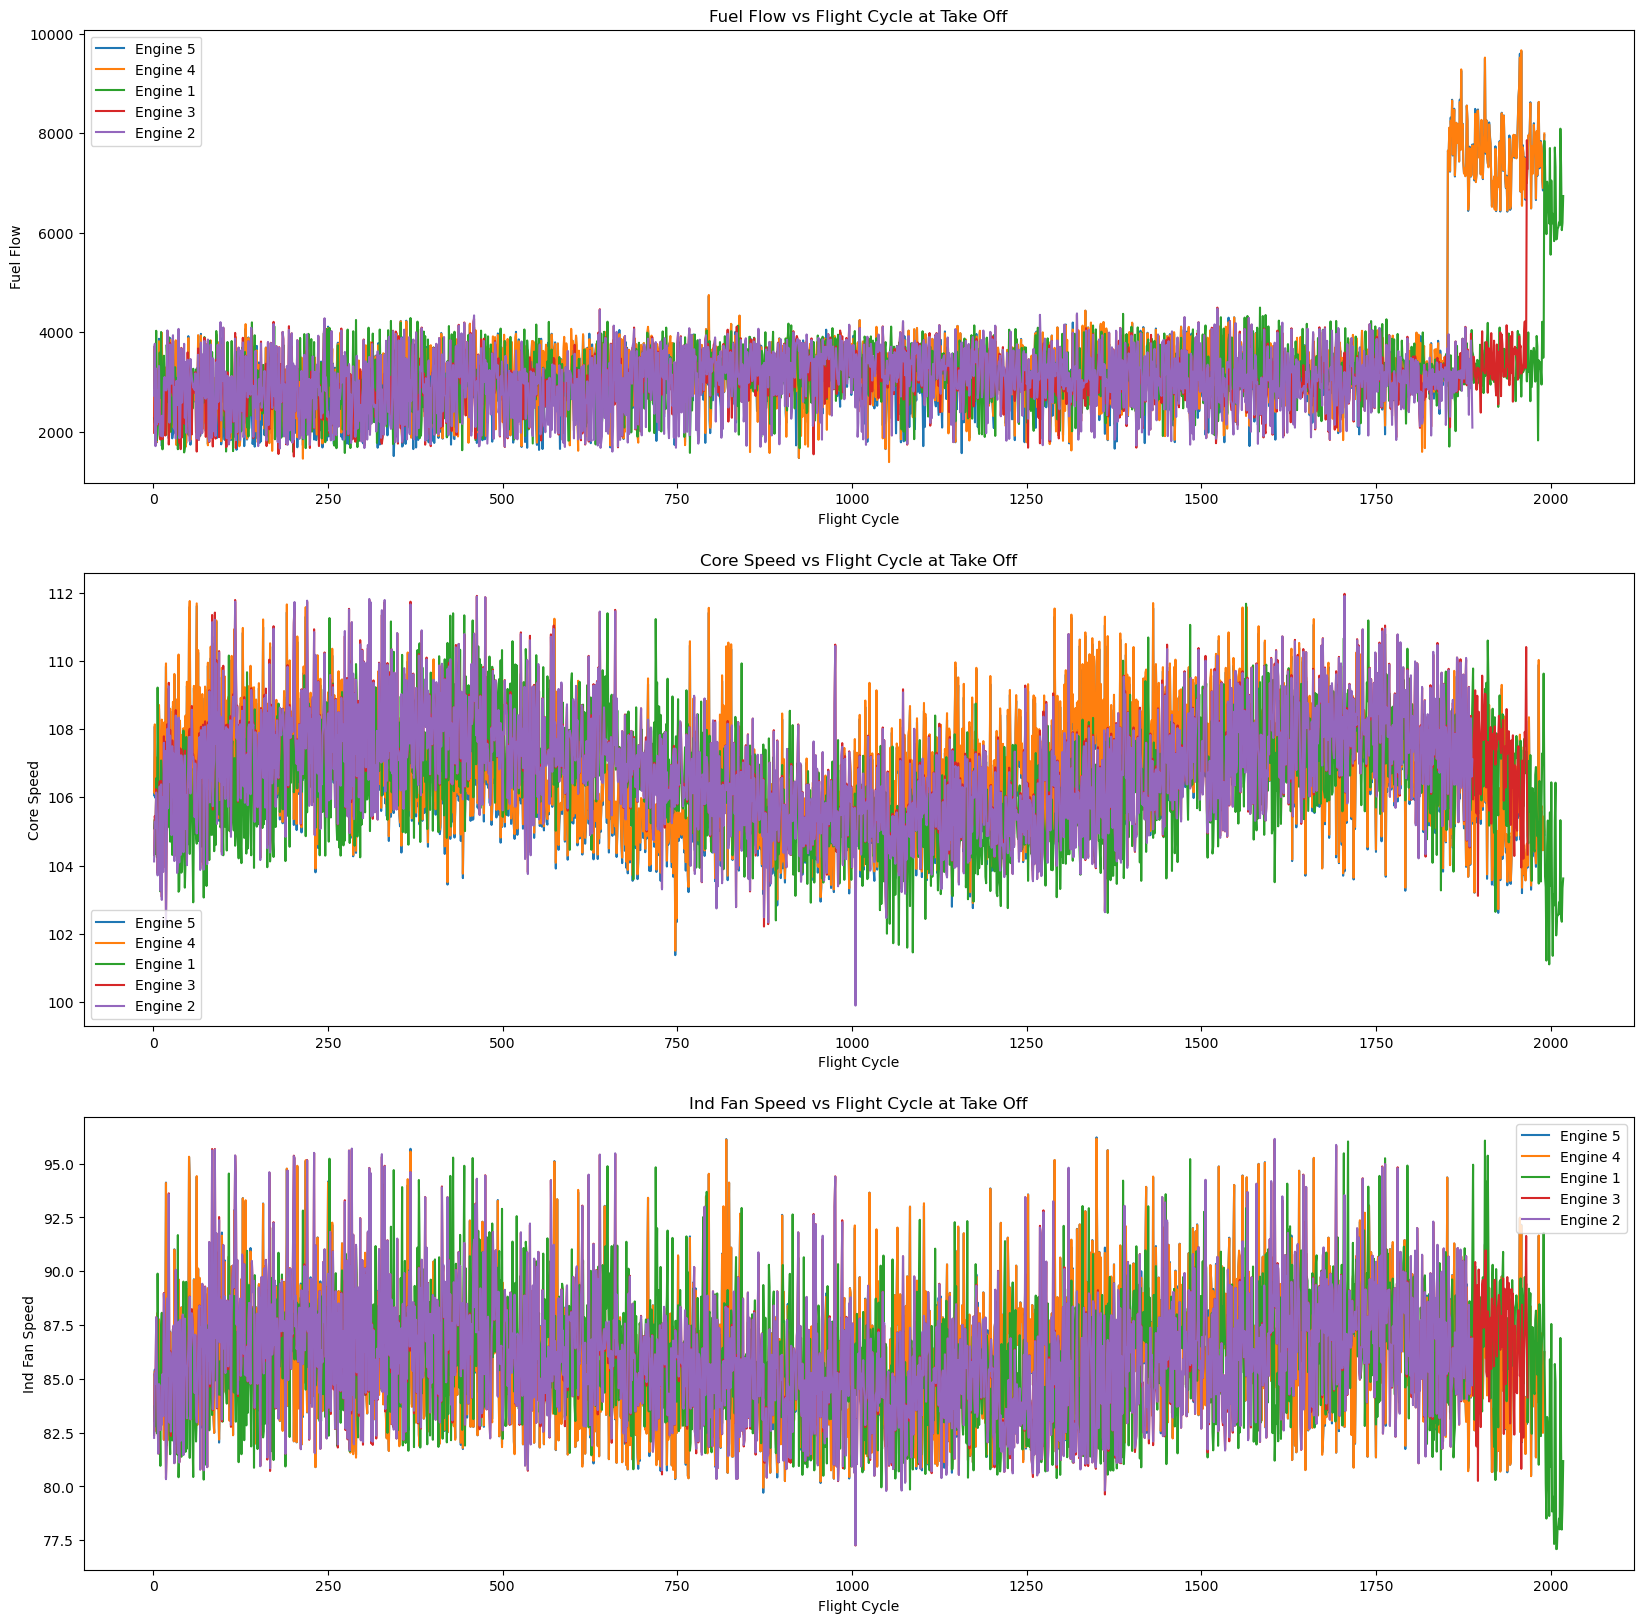

In [72]:
# lets plot flight cycles vs fuel flow, core speed, and ind fan speed for each engine at take off phase only
# store the index of the take off phase for each engine in a dictionary
# take off phase and flight cycle 
take_off_index = {}
for i in df['engine'].unique():
    take_off_index[i] = df[(df['engine'] == i) & (df['flight_phase'] == 'TAKEOFF')].index

# plot
plt.figure(figsize=(20, 20))
plt.subplot(3, 1, 1)
for i in take_off_index.keys():
    plt.plot(df.loc[take_off_index[i]]['flight_cycle'], df.loc[take_off_index[i]]['fuel_flow'], label='Engine ' + str(i))
plt.xlabel('Flight Cycle')
plt.ylabel('Fuel Flow')
plt.legend()
plt.title('Fuel Flow vs Flight Cycle at Take Off')
plt.subplot(3, 1, 2)
for i in take_off_index.keys():
    plt.plot(df.loc[take_off_index[i]]['flight_cycle'], df.loc[take_off_index[i]]['core_speed'], label='Engine ' + str(i))
plt.xlabel('Flight Cycle')
plt.ylabel('Core Speed')
plt.legend()
plt.title('Core Speed vs Flight Cycle at Take Off')
plt.subplot(3, 1, 3)
for i in take_off_index.keys():
    plt.plot(df.loc[take_off_index[i]]['flight_cycle'], df.loc[take_off_index[i]]['ind_fan_speed'], label='Engine ' + str(i))
plt.xlabel('Flight Cycle')
plt.ylabel('Ind Fan Speed')
plt.legend()
plt.title('Ind Fan Speed vs Flight Cycle at Take Off')
plt.show()



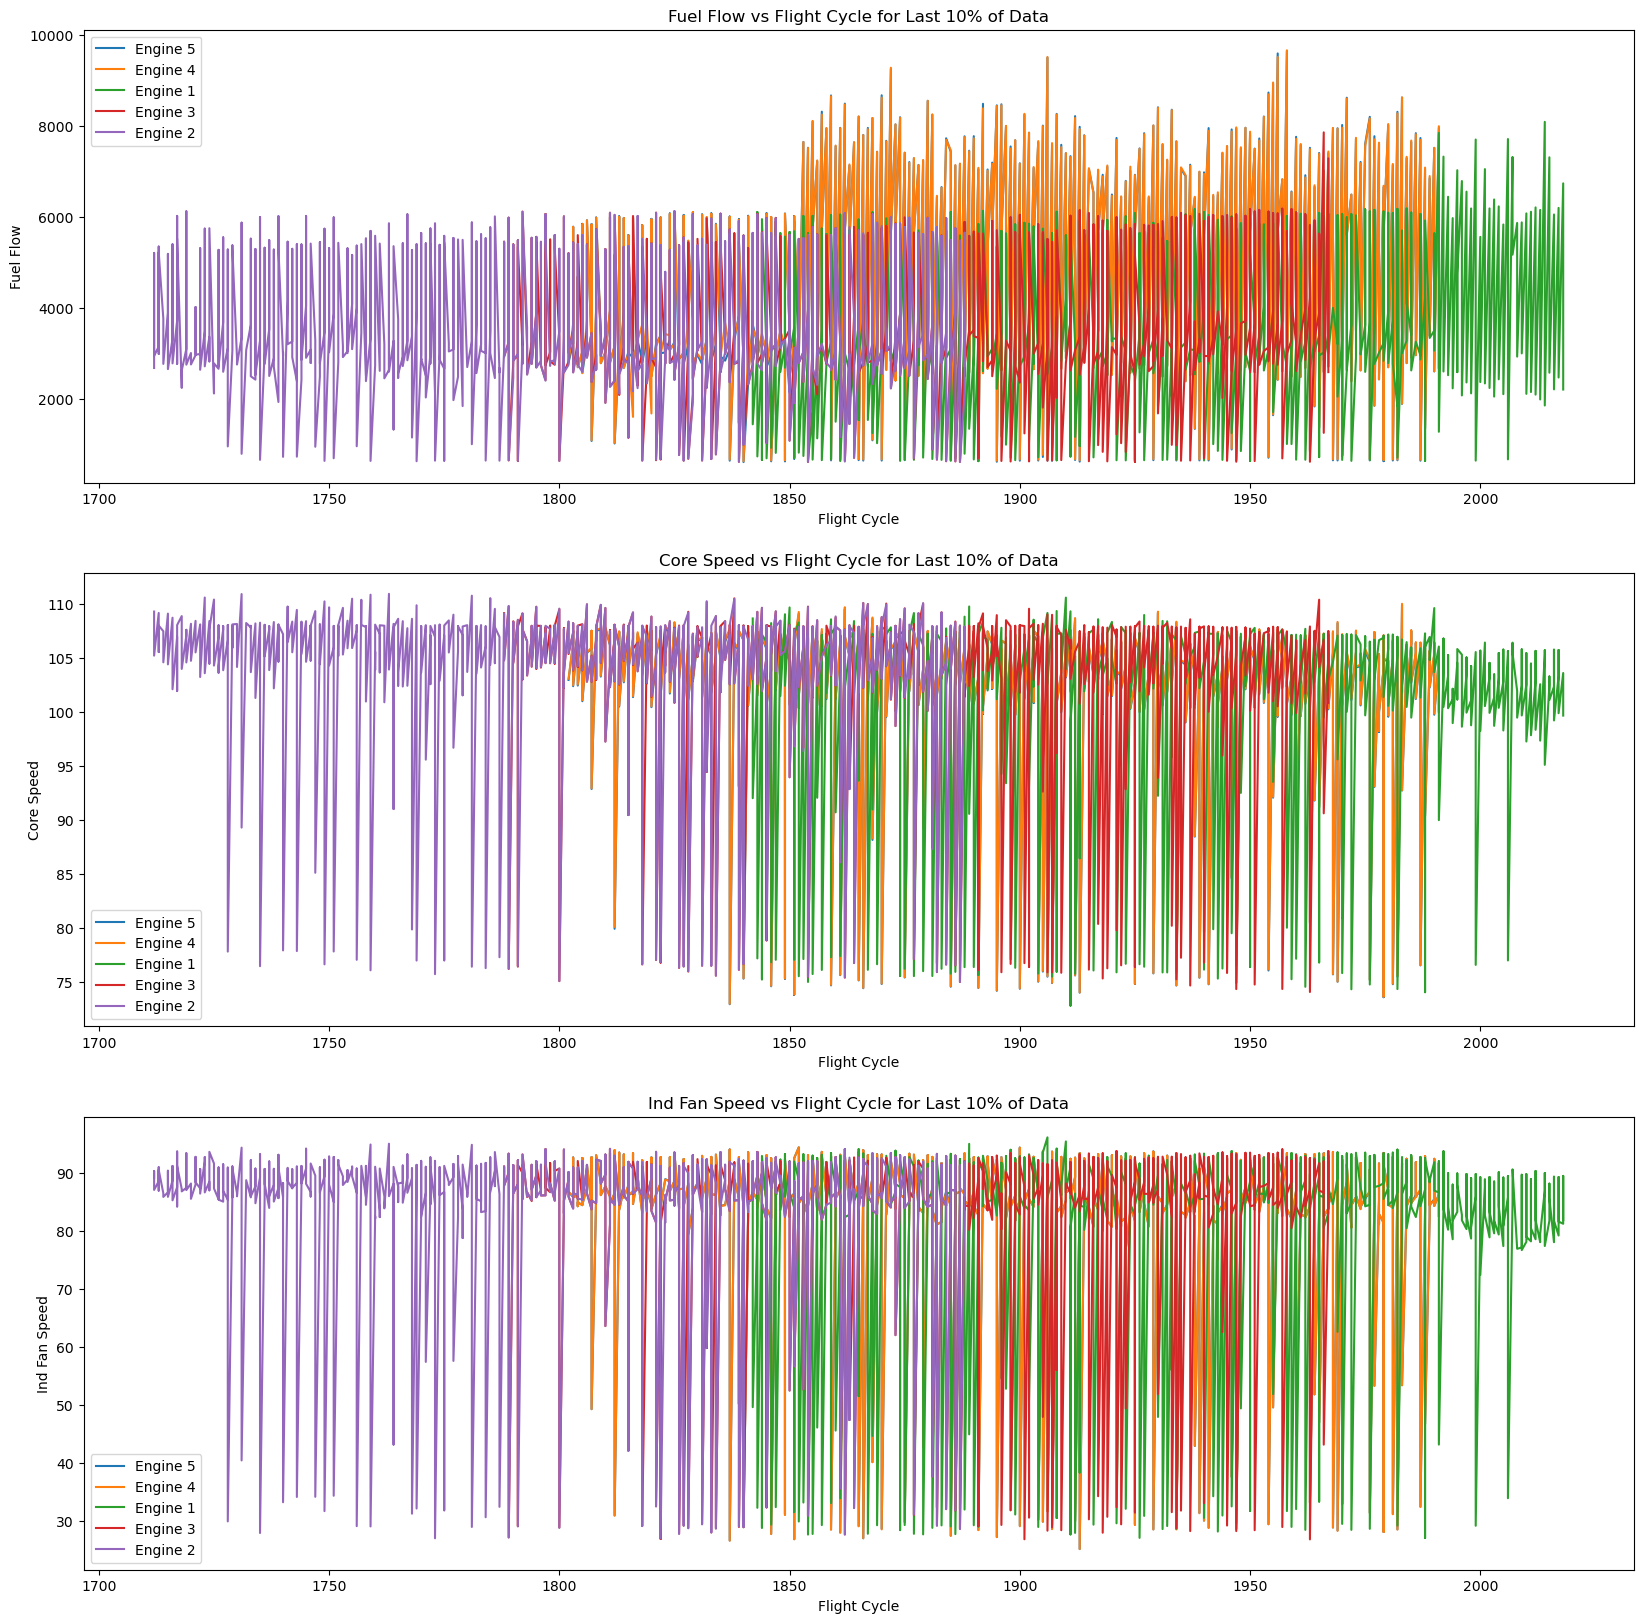

In [73]:
# lets focus on last 10% of the data for each engine in our plot
# store the index of the last 10% of the data for each engine in a dictionary
last_10_index = {}
for i in df['engine'].unique():
    last_10_index[i] = df[df['engine'] == i].index[-int(0.1*len(df[df['engine'] == i])):]
    
# plot
plt.figure(figsize=(20, 20))
plt.subplot(3, 1, 1)
for i in last_10_index.keys():
    plt.plot(df.loc[last_10_index[i]]['flight_cycle'], df.loc[last_10_index[i]]['fuel_flow'], label='Engine ' + str(i))
plt.xlabel('Flight Cycle')
plt.ylabel('Fuel Flow')
plt.legend()
plt.title('Fuel Flow vs Flight Cycle for Last 10% of Data')
plt.subplot(3, 1, 2)
for i in last_10_index.keys():
    plt.plot(df.loc[last_10_index[i]]['flight_cycle'], df.loc[last_10_index[i]]['core_speed'], label='Engine ' + str(i))
plt.xlabel('Flight Cycle')
plt.ylabel('Core Speed')
plt.legend()
plt.title('Core Speed vs Flight Cycle for Last 10% of Data')
plt.subplot(3, 1, 3)
for i in last_10_index.keys():
    plt.plot(df.loc[last_10_index[i]]['flight_cycle'], df.loc[last_10_index[i]]['ind_fan_speed'], label='Engine ' + str(i))
plt.xlabel('Flight Cycle')
plt.ylabel('Ind Fan Speed')
plt.legend()
plt.title('Ind Fan Speed vs Flight Cycle for Last 10% of Data')
plt.show()
